# Phase 7 — Explainability

Two independent pieces, per CLAUDE.md:
1. **Tabular feature importance** (this notebook, below) -- logistic regression coefficients from the EHR-only model (Phase 5), refit on the full 298-patient MRI cohort for a single representative set of weights to interpret.
2. **Grad-CAM on the CNN branch** -- visualizing which brain regions drove each imaging prediction. This needs an actual trained checkpoint (`data/processed/checkpoints/mri_fold{k}.pt`), which only exists on the Kaggle VM the imaging model was trained on -- checkpoints are correctly gitignored (never committed, per CLAUDE.md's "no large binaries" rule) and weren't part of what got pulled back locally (only the embeddings/metrics CSVs were). This section is a placeholder until at least one fold's checkpoint is available locally.

## Tabular feature importance

Refitting rather than reusing one of Phase 5's 5 per-fold models: those were each deliberately trained on only ~238 patients (holding out a fold for evaluation). For *explaining* what the EHR branch has learned -- not evaluating it -- one logistic regression fit on the full 298-patient cohort gives a single, more stable set of coefficients to interpret, using the same `build_ehr_pipeline()` from Phase 3.

Coefficients over standardized, one-hot encoded features are used directly (not SHAP) -- logistic regression is already linearly interpretable, so a coefficient table is the natural fit rather than adding a post-hoc explainer on top of an inherently transparent model. Because every numeric feature was standardized before fitting, coefficient *magnitude* is directly comparable across features (a raw age coefficient and a raw glucose coefficient aren't comparable on their original scales, but their standardized versions are) -- this is the same reasoning behind standardizing before comparing weights in a scorecard.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

sys.path.insert(0, str(Path("..") / "src" / "data"))
from ehr_features import build_ehr_pipeline
from folds import load_patient_folds

DATA_DIR = Path("..") / "data" / "processed"
cohort = pd.read_csv(DATA_DIR / "patient_cohort.csv")
folds_df = load_patient_folds(DATA_DIR / "patient_folds.csv")
mri_cohort = cohort[cohort["patient_id"].isin(folds_df["patient_id"])].reset_index(drop=True)
mri_cohort.shape

(298, 12)

In [2]:
pipeline = build_ehr_pipeline()
X = pipeline.fit_transform(mri_cohort)
y = mri_cohort["label"].values

model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
model.fit(X, y)

feature_names = pipeline.get_feature_names_out()
importance_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": model.coef_[0],
    "odds_ratio": np.exp(model.coef_[0]),
}).sort_values("coefficient", key=np.abs, ascending=False).reset_index(drop=True)

importance_df

,feature,coefficient,odds_ratio
0,numeric__age,0.703419,2.020650
1,numeric__systolic_bp,0.338232,1.402466
2,numeric__missingindicator_total_cholesterol,0.311693,1.365735
3,numeric__missingindicator_hdl_cholesterol,0.311693,1.365735
4,numeric__missingindicator_diastolic_bp,-0.170859,0.842940
5,numeric__missingindicator_systolic_bp,-0.170859,0.842940
6,numeric__missingindicator_bmi,-0.170859,0.842940
7,categorical__smoking_status_Never smoker,0.161286,1.175021
8,numeric__missingindicator_glucose,-0.137835,0.871243
9,categorical__smoking_status_Former smoker,-0.123232,0.884058


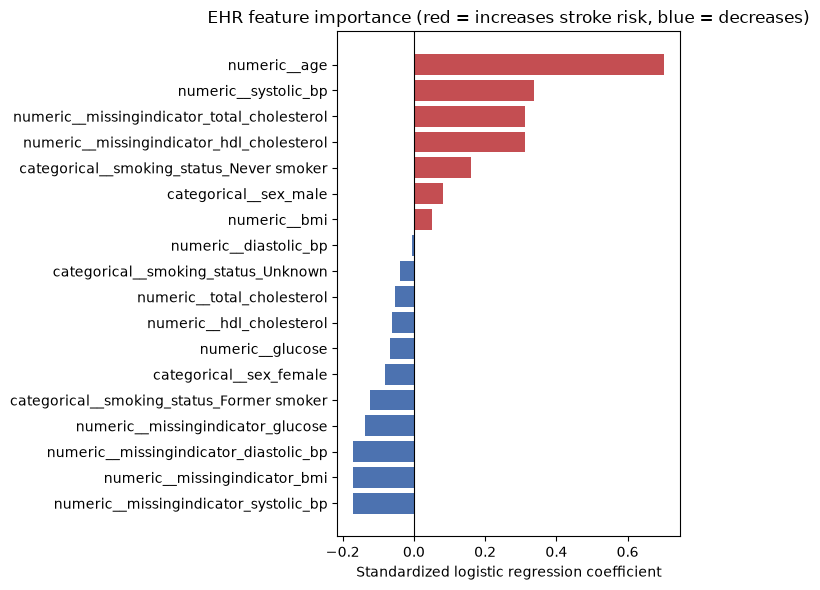

In [3]:
plot_df = importance_df.sort_values("coefficient")
colors = ["#C44E52" if c > 0 else "#4C72B0" for c in plot_df["coefficient"]]

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(plot_df["feature"], plot_df["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Standardized logistic regression coefficient")
ax.set_title("EHR feature importance (red = increases stroke risk, blue = decreases)")
plt.tight_layout()
plt.show()

### Interpretation

- **Age dominates** (coefficient 0.70, odds ratio ~2.0) -- a one-standard-deviation increase in age roughly doubles the modeled odds of stroke, holding everything else fixed. This matches the EDA notebook's finding that age had the strongest raw correlation with the label (0.45) of any feature.
- **Systolic BP is second** (odds ratio ~1.4), consistent with hypertension's well-known link to stroke risk.
- **The missing-indicator flags for total/HDL cholesterol carry real, positive weight** (odds ratio ~1.37 each, and identical to each other) -- patients missing a lipid panel show *higher* modeled stroke risk. The BP/BMI missing-indicators instead carry negative, and also identical-to-each-other, weight. The pairwise-identical coefficients aren't a coincidence: total and HDL cholesterol come from the same lab panel (missing together), and diastolic BP/systolic BP/BMI are all vitals recorded in the same encounter type (also missing together) -- so within each group, the missing-indicator columns are essentially duplicate features, and the model has no way to tell them apart. The direction itself is a plausible signal about care-seeking patterns in this synthetic population (patients who skip labs vs. vitals checks look different), but should be read as "some kind of missingness pattern matters here" rather than "lipid panels specifically."
- **Sex and smoking status contribute comparatively little** relative to age and BP -- their bars are visibly the smallest.

## Grad-CAM on the CNN branch (pending)

Needs a real trained checkpoint (`data/processed/checkpoints/mri_fold0.pt`) to load `MRIClassifier` (see `src/models/mri_model.py`) and run `pytorch-grad-cam` against its final convolutional layer -- not available locally yet. This section will be completed once that file is brought back from Kaggle.